In [ ]:
# Parts of this script were generated using generative AI (GPT-4o, GPT-4.1, GPT-5 mini through GitHub Copilot on Microsoft VS Code). All code, input data and results were manually reviewed ane edited. The author takes full responsibility for this work. The software is provided ``as is'' without any express or implied warranties.

import pandas as pd
import matplotlib.pyplot as plt
from SALib.analyze import delta,pawn
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import scipy.stats

pd.set_option('future.no_silent_downcasting', True)

/tmp/ipykernel_2292/322134122.py:10: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [3]:
sheet_location = "Case_Study_Analysis.xlsx"
df_input = pd.read_excel(sheet_location, sheet_name=["ChipSat-1 Trade", "AI4Space Trade", "POQUITO Trade", "ChiPySat Trade"])
# Append project number to each dataframe
for i, df in enumerate(df_input.values()):
    df["Project"] = i + 1
df_input = pd.concat(df_input.values(), ignore_index=True)

risk_map = { "Lower": -1, "Base": 0, "Higher": 1 }
df_input.replace({"Risk": risk_map}, inplace=True)

df_input

,CF #,Name,Applied,Cost,Time,Risk,Project
0,0,Baseline,NaN,8930,478,0,1
1,1,Bypassing structural/thermal analysis,Y,1390,-180,1,1
2,2,Soldering PCBs in-house,N,-2000,72,-1,1
3,3,Multi-step development,Y,1720,-120,-1,1
4,4,Short iterations,Y,695,-120,1,1
5,5,Iterating over partitions,Y,-1840,-50,1,1
6,6,Robust software framework,N,0,40,-1,1
7,0,Baseline,NaN,4900,468,0,2
8,1,Bypassing structural/thermal analysis,Y,0,-180,1,2
9,2,Soldering PCBs in-house,N,-1300,24,0,2


In [8]:
# Calculate relative value estimations for each treatment, for each project

relative_map = { 
    "Time": True,
    "Cost": True,
    "Risk": False
}

df = df_input.copy()

# Convert relative map columns with True to float64
df = df.astype({key: np.float64 for key, relative in relative_map.items() if relative})

for project in df["Project"].unique():
    project_mask = df["Project"] == project
    df_project = df[project_mask]
    baseline = df_project[df_project["CF #"] == 0]
    
    for key, relative in relative_map.items():
        baseline_value = baseline[key].iloc[0]

        if relative:
            not_applied_mask = project_mask & (df["Applied"] == "N")
            df.loc[not_applied_mask, key] = 1.0 + df.loc[not_applied_mask, key] / baseline_value

            applied_mask = project_mask & (df["Applied"] == "Y")
            df.loc[applied_mask, key] = baseline_value / (baseline_value - df.loc[applied_mask, key])
        else:
            not_applied_mask = project_mask & (df["Applied"] == "N")
            df.loc[not_applied_mask, key] = baseline_value + df.loc[not_applied_mask, key]

            applied_mask = project_mask & (df["Applied"] == "Y")
            df.loc[applied_mask, key] = baseline_value + df.loc[applied_mask, key]


for key, relative in relative_map.items():
    if relative:
        df.loc[df["Applied"].isna(), key] = 1

df

,CF #,Name,Applied,Cost,Time,Risk,Project
0,0,Baseline,NaN,1.0000,1.0000,0,1
1,1,Bypassing structural/thermal analysis,Y,1.1844,0.7264,1,1
2,2,Soldering PCBs in-house,N,0.7760,1.1506,-1,1
3,3,Multi-step development,Y,1.2386,0.7993,-1,1
4,4,Short iterations,Y,1.0844,0.7993,1,1
5,5,Iterating over partitions,Y,0.8292,0.9053,1,1
6,6,Robust software framework,N,1.0000,1.0837,-1,1
7,0,Baseline,NaN,1.0000,1.0000,0,2
8,1,Bypassing structural/thermal analysis,Y,1.0000,0.7222,1,2
9,2,Soldering PCBs in-house,N,0.7347,1.0513,0,2


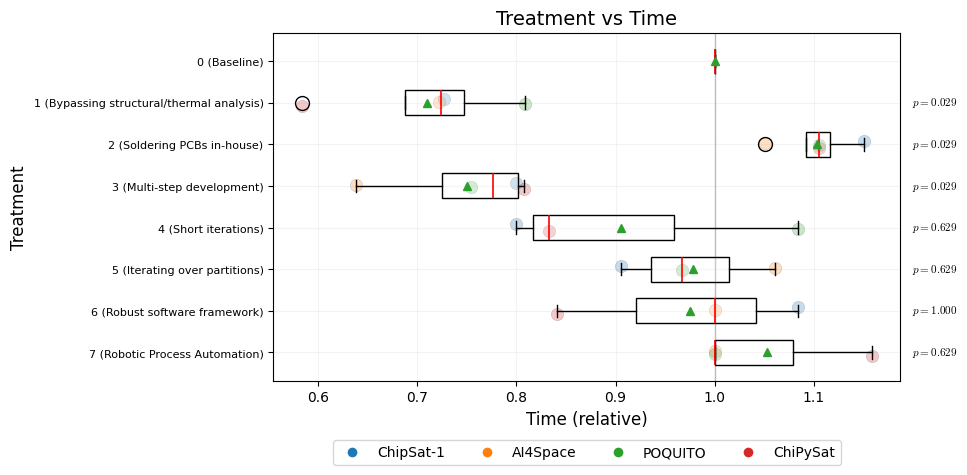

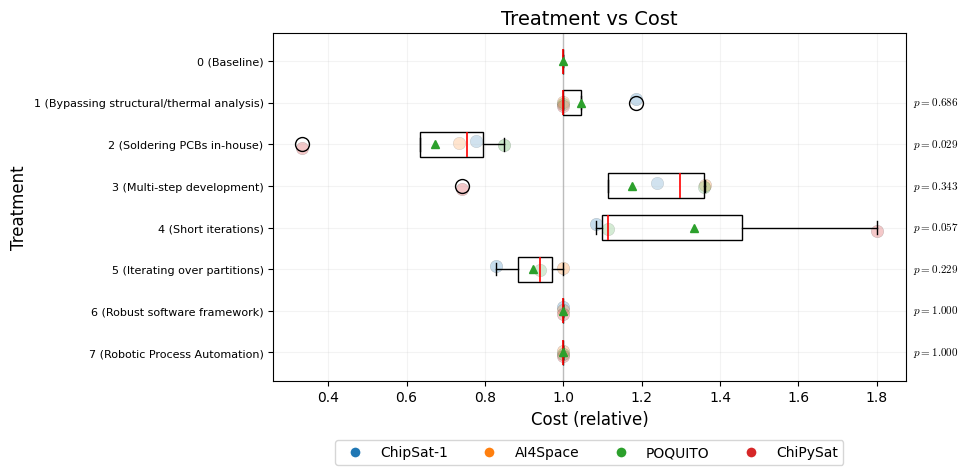

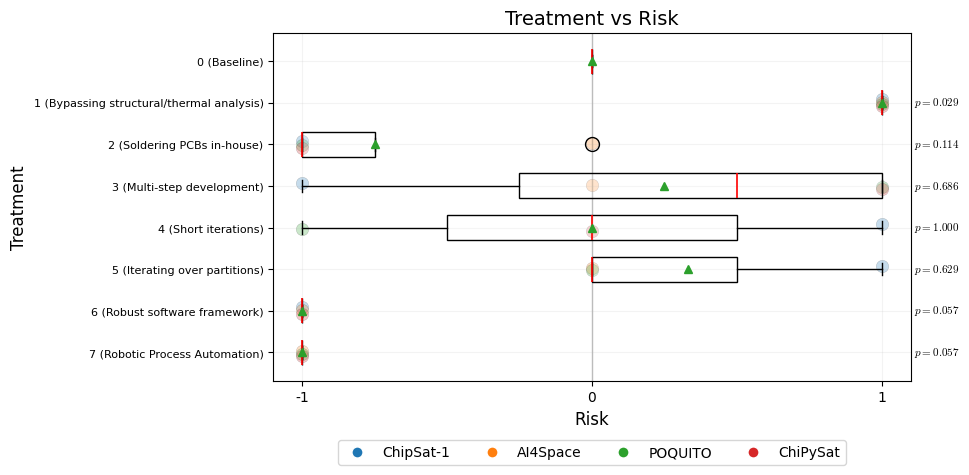

In [9]:
projects = df["Project"].unique()
project_list = [ "ChipSat-1", "AI4Space", "POQUITO", "ChiPySat" ]
cmap = plt.get_cmap('tab10')
colors = {project: cmap(i) for i, project in enumerate(projects)}

for parameter, relative in relative_map.items():
    treatments = np.sort(df['CF #'].unique())
    treatment_labels = ["{} ({})".format(t, df.loc[df['CF #'] == t, 'Name'].iloc[0]) for t in treatments]
    data_by_t = [df.loc[df['CF #'] == t, parameter].values for t in treatments]

    fig, ax = plt.subplots(figsize=(14 * 0.7, 7 * 0.7))

    # base line
    ax.axvline(x=df.loc[df['CF #'] == 0, parameter].iloc[0], color='gray', alpha=0.5, linestyle='-', linewidth=1.0, zorder=-1)

    # scatter background: jitter points and color by project
    rng = np.random.default_rng(0)
    for proj in projects:
        proj_mask = (df['Project'] == proj) & (df['CF #'] != 0)
        xs = df.loc[proj_mask, 'CF #'].values
        ys = df.loc[proj_mask, parameter].values
        if len(xs):
            jitter = (proj - (len(projects) + 1) / 2) * (0.16 / (len(projects) - 1))
            xs, ys = ys, xs + jitter
            ax.scatter(xs, ys, color=colors.get(proj, 'gray'), alpha=0.25, s=80, edgecolors='k', linewidths=0.3, zorder=1)

    bp = ax.boxplot(data_by_t, positions=treatments, widths=0.6, patch_artist=True, notch=False, manage_ticks=False, zorder=2, showmeans=True, orientation='horizontal')
    # style boxes to be transparent so background points remain visible
    for box in bp['boxes']:
        box.set(facecolor=(1, 1, 1, 0.2), edgecolor='black', linewidth=1.0)
    # for whisker in bp['whiskers']:
    #     whisker.set(color='black', linewidth=0.8)
    # for cap in bp['caps']:
    #     cap.set(color='black', linewidth=0.8)
    for median in bp['medians']:
        median.set(color='red', linewidth=1.2)
    for flier in bp['fliers']:
        flier.set(marker='o', color='black', alpha=1, linewidth=1, ms=10)

    # statistics
    for t in treatments:
        b = df.loc[df['CF #'] == 0, parameter].astype(np.float64)
        x = df.loc[df['CF #'] == t, parameter].astype(np.float64)
        statistics = scipy.stats.mannwhitneyu(b, x, alternative='two-sided', method='exact')

        # Stick p-value on the right side of the plot
        y_pos = t
        x_pos = ax.get_xlim()[1] * 1.01
        if t != 0:
            ax.text(x_pos, y_pos, f'$p={statistics.pvalue:.3f}$', fontsize=8, verticalalignment='center', horizontalalignment='left', math_fontfamily='cm')

    ax.set_ylabel('Treatment', fontsize=12)
    ax.set_xlabel(parameter + (" (relative)" if relative else ""), fontsize=12)
    ax.set_title(f'Treatment vs {parameter}', fontsize=14)
    ax.set_yticks(treatments)
    ax.set_yticklabels(treatment_labels, fontsize=8)
    # ax.tick_params( axis='y', which='major', length=15 )
    ax.yaxis.set_inverted(True)
    ax.grid(True, alpha=0.15)

    if not relative:
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # legend for projects
    handles = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[p], markersize=8, label=project_list[p - 1]) for p in projects]
    ax.legend(handles=handles, bbox_to_anchor=(0.5, -0.15), loc='upper center', fontsize=10, ncol=4)
    #ax.legend(handles=handles, title='Project', bbox_to_anchor=(1,0.5), loc='center left', fontsize=8, ncol=1)

    plt.tight_layout()
    plt.savefig(f'../media/analyses/specific_sensitivity_{parameter}.pdf')

In [10]:
# Calculate summary statistics for each treatment and parameter
summary_stats = []

for parameter in relative_map.keys():
    for treatment in treatments[1:]:
        treatment_data = df[df['CF #'] == treatment][parameter]
        
        summary_stats.append({
            'Parameter': parameter,
            'Treatment': treatment,
            'Treatment Name': df[df['CF #'] == treatment]['Name'].iloc[0],
            'Average': treatment_data.mean(),
            'RMS': np.sqrt(np.mean((treatment_data - 1)**2)),
            # 'Median': treatment_data.median(),
            'Variance': treatment_data.var(),
            "M-W p-value": scipy.stats.mannwhitneyu(
                df[df['CF #'] == 0][parameter].astype(np.float64),
                treatment_data.astype(np.float64),
                alternative='two-sided',
                method='exact'
            ).pvalue
        })

summary_df = pd.DataFrame(summary_stats)

# Display with better formatting
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)

#print(summary_df.to_string(index=False))

summary_df.style.format({
    'Average': '{:.4f}',
    # 'Median': '{:.4f}',
    'RMS': '{:.4f}',
    'Variance': '{:.6f}',
    "M-W p-value": '{:.6f}'
}).background_gradient(subset=['Average', 'RMS', "M-W p-value"], cmap='RdYlGn_r')

,Parameter,Treatment,Treatment Name,Average,RMS,Variance,M-W p-value
0,Time,1,Bypassing structural/thermal analysis,0.7101,0.3010,0.008709,0.028571
1,Time,2,Soldering PCBs in-house,1.1031,0.1090,0.001651,0.028571
2,Time,3,Multi-step development,0.7498,0.2591,0.006071,0.028571
3,Time,4,Short iterations,0.9057,0.1583,0.024228,0.628571
4,Time,5,Iterating over partitions,0.9778,0.0679,0.006167,0.628571
5,Time,6,Robust software framework,0.9750,0.1036,0.015160,1.000000
6,Time,7,Robotic Process Automation,1.0529,0.0916,0.008398,0.628571
7,Cost,1,Bypassing structural/thermal analysis,1.0461,0.0922,0.008496,0.685714
8,Cost,2,Soldering PCBs in-house,0.6734,0.3833,0.053675,0.028571
9,Cost,3,Multi-step development,1.1749,0.3097,0.087068,0.342857


In [11]:
# LaTeX table
booktabs_data = []

def format_pvalue(val):
    if val < 0.1:
        return f'\\textcolor{{nice}}{{{val:.3f}}}'
    else:
        return f'\\textcolor{{bad}}{{{val:.3f}}}'

for treatment in treatments[1:]:
    row = []
    row.append("{}. {}".format(treatment, df[df['CF #'] == treatment]['Name'].iloc[0]))
    
    for i, parameter in enumerate(relative_map.keys()):
        summary_row = summary_df[
            (summary_df['Parameter'] == parameter) &
            (summary_df['Treatment'] == treatment)
        ]

        if i != 0:
            row.append(' ')  # space

        row.append(f"{summary_row['Average'].values[0]:.3f}")
        row.append(f"{summary_row['Variance'].values[0]:.4f}")
        row.append(format_pvalue(summary_row['M-W p-value'].values[0]))
    
    booktabs_data.append(row)

booktabs_df = pd.DataFrame(booktabs_data)

latex_lines = [
    r'\begin{tabular}{l' + 'l@{\\hspace{1em}}'.join(['S[table-format=1.3]S[table-format=1.4]S[table-format=1.3]'] * len(relative_map)) + '}',
    r'\toprule'
]

header1 = ''
for i, param in enumerate(relative_map.keys()):
    if i != 0:
        header1 += ' & '  # space
    header1 += f' & \\multicolumn{{3}}{{c}}{{\\textbf{{{param}}}}}'
header1 += r' \\'
latex_lines.append(header1)

for i, _ in enumerate(relative_map.keys()):
    latex_lines.append(f'\\cmidrule(lr){{{2 + i*4}-{4 + i*4}}}')

header2 = '\\multicolumn{1}{c}{\\textbf{Treatment}}'
for i, param in enumerate(relative_map.keys()):
        if i != 0:
            header2 += ' & '  # space
        header2 += r' & {Avg} & {Variance} & {$p$-value}'
header2 += r' \\'
latex_lines.append(header2)
latex_lines.append(r'\midrule')

# Data rows
for idx, row in booktabs_df.iterrows():
    line = ' & '.join(map(str, row))
    
    line += r' \\'
    latex_lines.append(line)

latex_lines.extend([
    r'\bottomrule',
    r'\end{tabular}',
])

latex_table = '\n'.join(latex_lines)
print(latex_table)

\begin{tabular}{lS[table-format=1.3]S[table-format=1.4]S[table-format=1.3]l@{\hspace{1em}}S[table-format=1.3]S[table-format=1.4]S[table-format=1.3]l@{\hspace{1em}}S[table-format=1.3]S[table-format=1.4]S[table-format=1.3]}
\toprule
 & \multicolumn{3}{c}{\textbf{Time}} &  & \multicolumn{3}{c}{\textbf{Cost}} &  & \multicolumn{3}{c}{\textbf{Risk}} \\
\cmidrule(lr){2-4}
\cmidrule(lr){6-8}
\cmidrule(lr){10-12}
\multicolumn{1}{c}{\textbf{Treatment}} & {Avg} & {Variance} & {$p$-value} &  & {Avg} & {Variance} & {$p$-value} &  & {Avg} & {Variance} & {$p$-value} \\
\midrule
1. Bypassing structural/thermal analysis & 0.710 & 0.0087 & \textcolor{nice}{0.029} &   & 1.046 & 0.0085 & \textcolor{bad}{0.686} &   & 1.000 & 0.0000 & \textcolor{nice}{0.029} \\
2. Soldering PCBs in-house & 1.103 & 0.0017 & \textcolor{nice}{0.029} &   & 0.673 & 0.0537 & \textcolor{nice}{0.029} &   & -0.750 & 0.2500 & \textcolor{bad}{0.114} \\
3. Multi-step development & 0.750 & 0.0061 & \textcolor{nice}{0.029} &   & 1.175 & 

In [17]:
# Calculate summary statistics for ALL treatments for each parameter
summary_stats = []

df_total = df_input.copy()

# Convert relative map columns with True to float64
df_total = df_total.astype({key: np.float64 for key, relative in relative_map.items() if relative})

mapmap = {}

for project in df_total["Project"].unique():
    project_mask = df_total["Project"] == project
    df_project = df_total[project_mask]
    baseline = df_project[df_project["CF #"] == 0]

    mapmap[project] = {}
    
    for key, relative in relative_map.items():
        baseline_value = baseline[key].iloc[0]

        not_applied_mask = project_mask & (df_total["Applied"] == "N")
        total_not_applied = df_total.loc[not_applied_mask, key].sum()

        applied_mask = project_mask & (df_total["Applied"] == "Y")
        total_applied = df_total.loc[applied_mask, key].sum()

        total_0 = baseline_value - total_applied
        total_full = baseline_value + total_not_applied

        mapmap[project][key + '_0'] = total_0
        mapmap[project][key + '_full'] = total_full
        if relative:
            mapmap[project][key + '_rel'] = total_full / total_0
        else:
            mapmap[project][key + '_rel'] = total_full - total_0


df_map = pd.DataFrame(mapmap).T

for parameter in relative_map.keys():
    print("Average {} change: {:.4f}".format(parameter, df_map[parameter + '_rel'].mean()))

df_map

Average Time change: 0.5927
Average Cost change: 0.9345
Average Risk change: -0.7500


,Time_0,Time_full,Time_rel,Cost_0,Cost_full,Cost_rel,Risk_0,Risk_full,Risk_rel
1,948.0000,590.0000,0.6224,6965.0000,6930.0000,0.9950,-2.0000,-2.0000,0.0000
2,886.0000,492.0000,0.5553,3600.0000,3600.0000,1.0000,1.0000,0.0000,-1.0000
3,1213.0000,903.0000,0.7444,21380.0000,25780.0000,1.2058,-2.0000,-3.0000,-1.0000
4,468.0000,210.0000,0.4487,3350.0000,1800.0000,0.5373,-1.0000,-2.0000,-1.0000
